### Imports

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

### Load the Dataset
- Downloaded from Kaggle

In [53]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


### Inspect the data

In [54]:
print(df.shape)
print(df.dtypes)
print(df["Attrition"].value_counts())

(1470, 35)
Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears           int64
Tra

### Encode categorical variables

In [55]:
X_raw = df.drop("Attrition", axis=1)
y_raw = df["Attrition"]

y = LabelEncoder().fit_transform(y_raw)

X = pd.get_dummies(X_raw, drop_first=True)

### Slipt feature and labels

In [56]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

### Full Bushy decision Tree

In [57]:
tree_full = DecisionTreeClassifier(random_state=42)
tree_full.fit(X_train, y_train)

train_pred_full = tree_full.predict(X_train)
test_pred_full = tree_full.predict(X_test)

train_acc_full = accuracy_score(y_train, train_pred_full)
test_acc_full = accuracy_score(y_test, test_pred_full)

print("Full Tree Train Accuracy:", train_acc_full)
print("Full tree Test Accuracy:", test_acc_full)

Full Tree Train Accuracy: 1.0
Full tree Test Accuracy: 0.7472826086956522


### Pruned Decision Tree

In [58]:
tree_pruned = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_pruned.fit(X_train, y_train)

train_pred_pruned = tree_pruned.predict(X_train)
test_pred_pruned = tree_pruned.predict(X_test)

train_acc_pruned = accuracy_score(y_train, train_pred_pruned)
test_acc_pruned = accuracy_score(y_test, test_pred_pruned)

print("Pruned tree train accuracy:", train_acc_pruned)
print("Pruned tree test accuracy:", test_acc_pruned)

Pruned tree train accuracy: 0.8765880217785844
Pruned tree test accuracy: 0.8233695652173914


### Gaussian Naive Bayes

In [59]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

train_pred_nb = nb_model.predict(X_train)
test_pred_nb = nb_model.predict(X_test)

train_acc_nb = accuracy_score(y_train, train_pred_nb)
test_acc_nb = accuracy_score(y_test, test_pred_nb)

print("Naive Bayes train accuracy:", train_acc_nb)
print("Naive Bayes Test accuracy:", test_acc_nb)

Naive Bayes train accuracy: 0.779491833030853
Naive Bayes Test accuracy: 0.7445652173913043


### Compare all models

In [60]:
results = pd.DataFrame({
    "Model": ["Full Tree", "Pruned Tree", "GaussianNB"],
    "Train Accuracy": [train_acc_full, train_acc_pruned, train_acc_nb],
    "Test Accuracy": [test_acc_full, test_acc_pruned, test_acc_nb]
})
print(results)

         Model  Train Accuracy  Test Accuracy
0    Full Tree        1.000000       0.747283
1  Pruned Tree        0.876588       0.823370
2   GaussianNB        0.779492       0.744565


### Correlation Matrix -> To inspect NB assumption

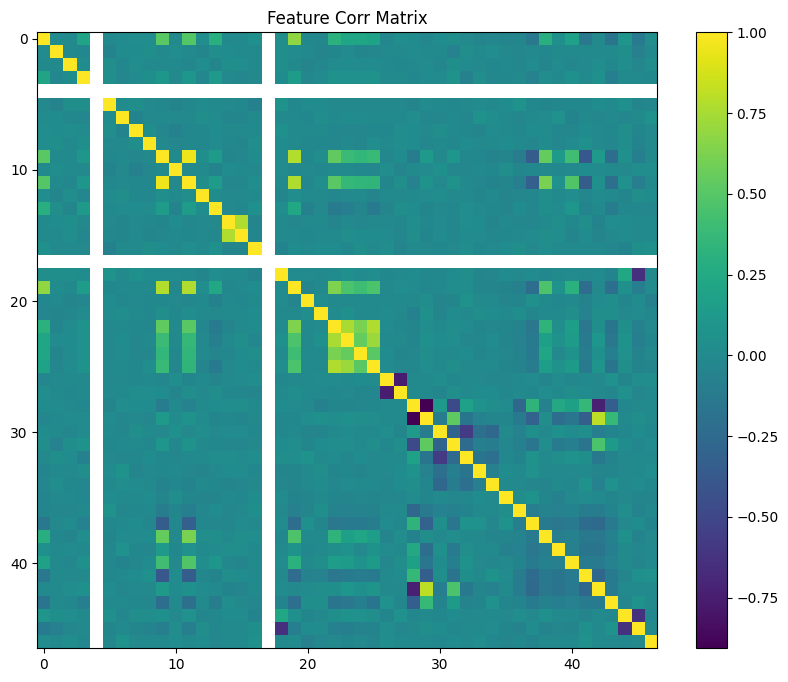

In [61]:
corr = X.corr()
plt.figure(figsize=(10,8))
plt.imshow(corr,aspect='auto')
plt.colorbar()
plt.title("Feature Corr Matrix")
plt.show()

### Strong Correlation only

In [62]:
strong_corr = corr.abs() > 0.7
print(strong_corr.sum().sort_values(ascending=False).head())

YearsInCurrentRole         3
MonthlyIncome              3
YearsWithCurrManager       3
Department_Sales           3
JobRole_Sales Executive    3
dtype: int64
